# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\data-1779767889227.csv")

In [3]:
df['bulan'] = pd.to_datetime(df['bulan'])

In [4]:
df = df.sort_values('bulan')

In [5]:
df.head()

,bulan,mcc_description,total_amount,amount_bulan_lalu,mom_growth_pct,status_mcc
0,2025-02-01,Accessory and Apparel Stores-Miscellaneous,457803281.0,140165632.0,226.62,Growth
231,2025-02-01,Automobile and Truck Dealers-(Used Only)-Sales,2000167.0,3567945.0,-43.94,Decline
2281,2025-02-01,Passenger Railways,11897000.0,24075000.0,-50.58,Decline
1364,2025-02-01,Family Clothing Stores,225069626.0,226983016.0,-0.84,Stable
513,2025-02-01,Campgrounds and Trailer Parks,752900.0,130000.0,479.15,Growth


In [6]:
bulan_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
    7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}

In [7]:
df['nama_bulan'] = df['bulan'].dt.month.map(bulan_map) + ' ' + df['bulan'].dt.year.astype(str)

In [8]:
df.head()

,bulan,mcc_description,total_amount,amount_bulan_lalu,mom_growth_pct,status_mcc,nama_bulan
0,2025-02-01,Accessory and Apparel Stores-Miscellaneous,457803281.0,140165632.0,226.62,Growth,Feb 2025
231,2025-02-01,Automobile and Truck Dealers-(Used Only)-Sales,2000167.0,3567945.0,-43.94,Decline,Feb 2025
2281,2025-02-01,Passenger Railways,11897000.0,24075000.0,-50.58,Decline,Feb 2025
1364,2025-02-01,Family Clothing Stores,225069626.0,226983016.0,-0.84,Stable,Feb 2025
513,2025-02-01,Campgrounds and Trailer Parks,752900.0,130000.0,479.15,Growth,Feb 2025


In [9]:
top_10_mcc = df.groupby('mcc_description')['mom_growth_pct'].mean().nlargest(10).index

In [10]:
df_top10 = df[df['mcc_description'].isin(top_10_mcc)]

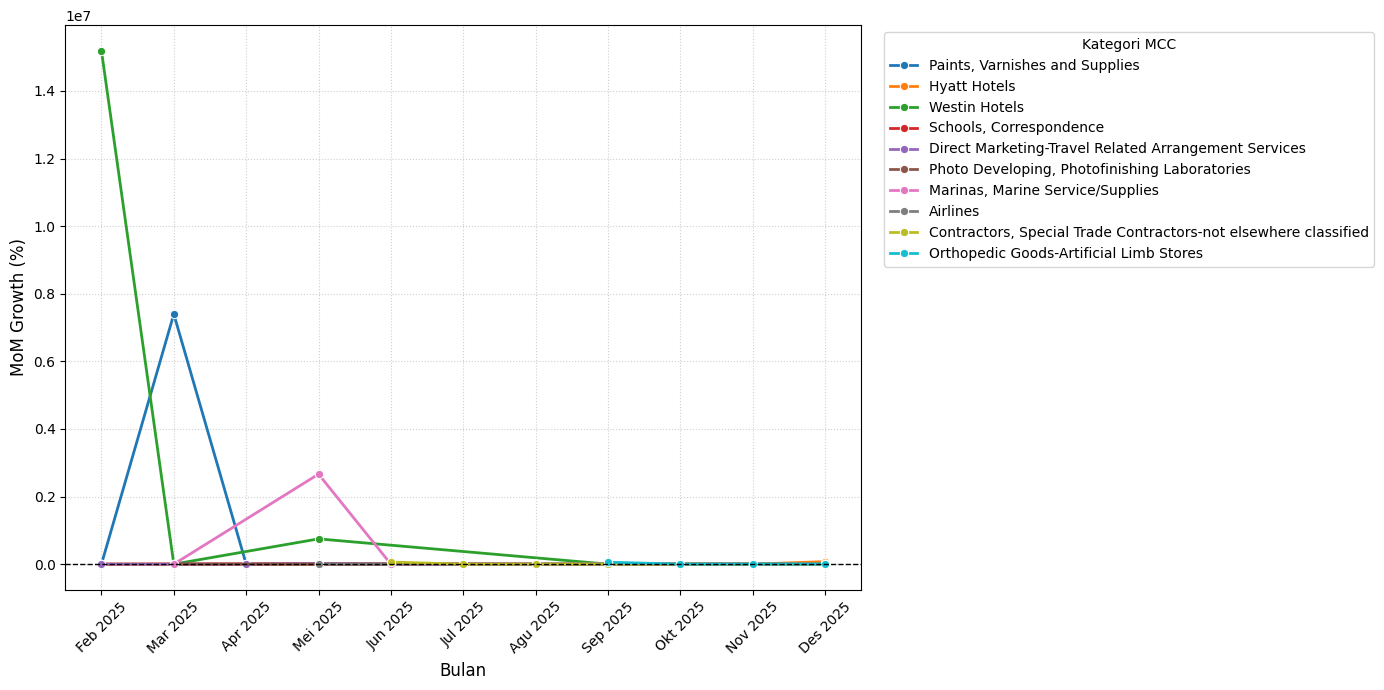

In [11]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_top10, 
    x='nama_bulan',       
    y='mom_growth_pct', 
    hue='mcc_description', 
    marker='o',
    linewidth=2,
    sort=False           
)

plt.xlabel('Bulan', fontsize=12)
plt.ylabel('MoM Growth (%)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', linewidth=1) 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Kategori MCC')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24140\3409143164.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


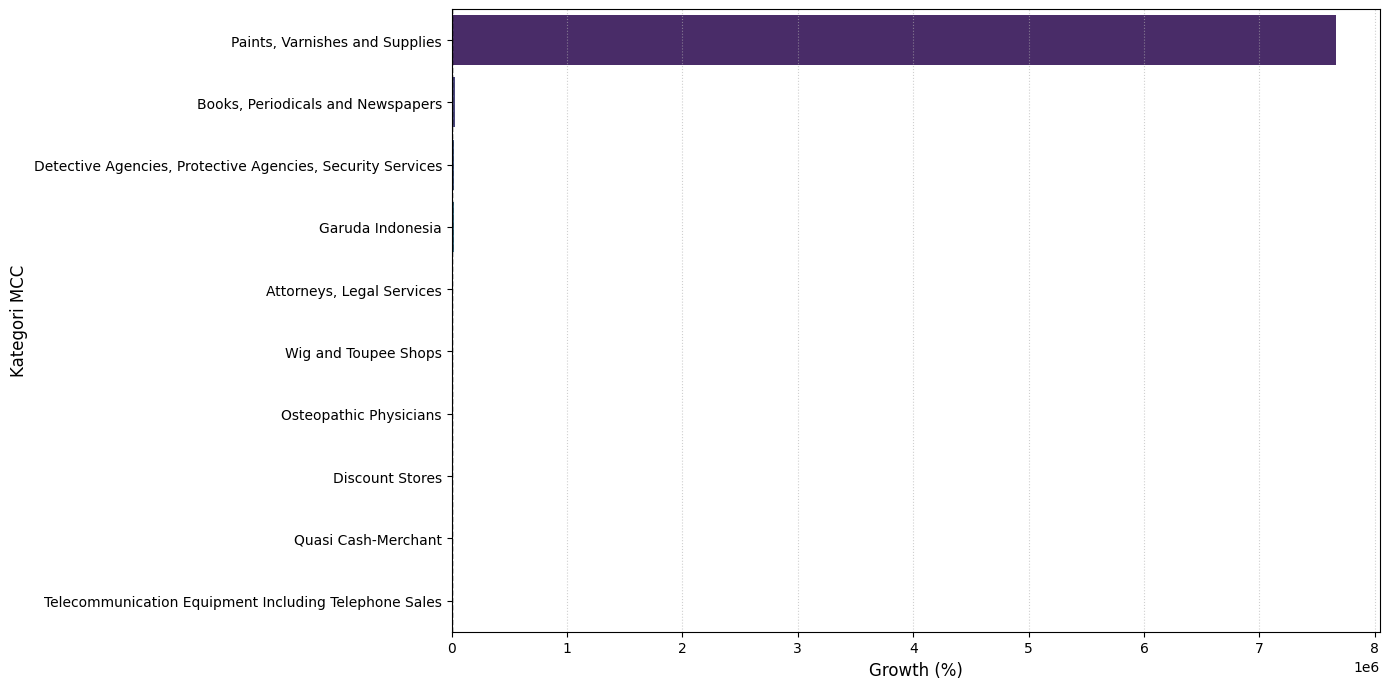

In [44]:
min_month = df['bulan'].dt.month.min()
max_month = df['bulan'].dt.month.max()

df_ytd = df[df['bulan'].dt.month.isin([min_month, max_month])].copy()
df_ytd['bulan_int'] = df_ytd['bulan'].dt.month

pivot_df = df_ytd.pivot(index='mcc_description', columns='bulan_int', values='total_amount')

pivot_df['growth_pct'] = ((pivot_df[max_month] - pivot_df[min_month]) / pivot_df[min_month]) * 100

top_10 = pivot_df.dropna().nlargest(10, 'growth_pct').reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_10,
    x='growth_pct',
    y='mcc_description',
    palette='viridis'
)

plt.xlabel('Growth (%)', fontsize=12)
plt.ylabel('Kategori MCC', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

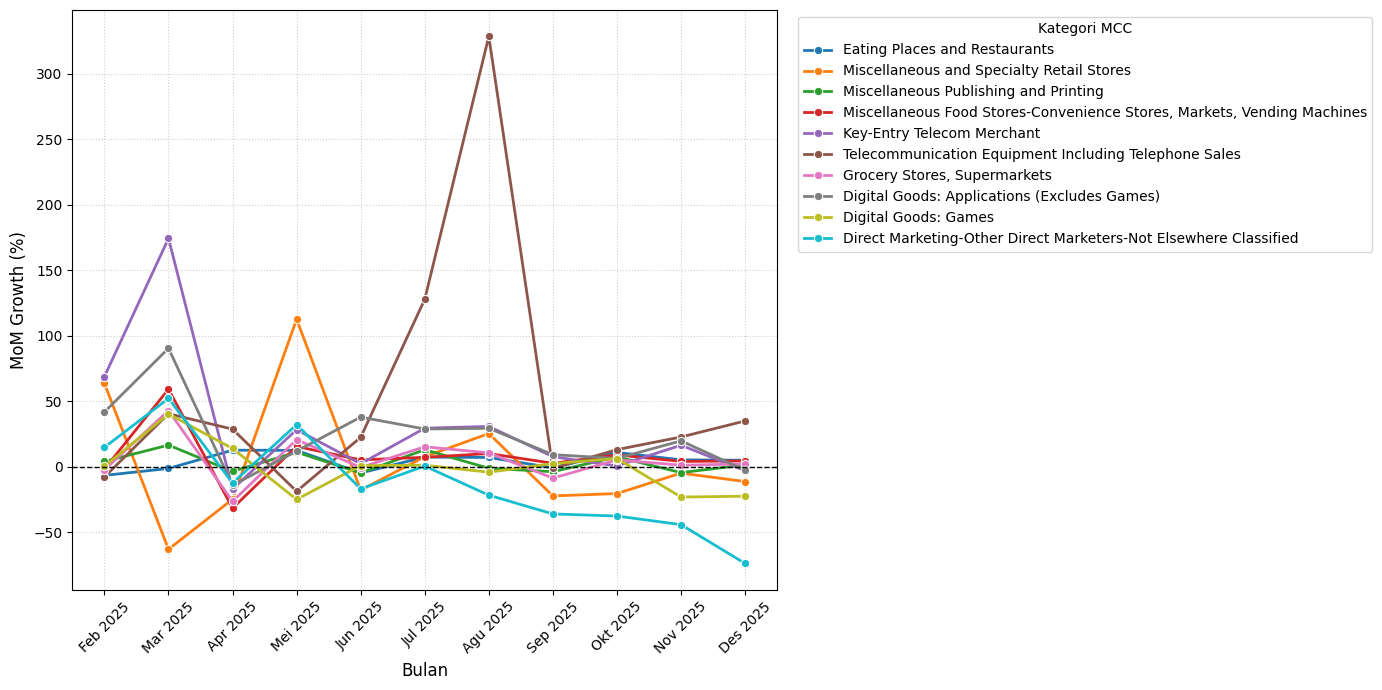

In [43]:
df['bulan'] = pd.to_datetime(df['bulan'])
df = df.sort_values('bulan')

bulan_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
    7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}
df['nama_bulan'] = df['bulan'].dt.month.map(bulan_map) + ' ' + df['bulan'].dt.year.astype(str)

top_10_mcc = df.groupby('mcc_description')['total_amount'].sum().nlargest(10).index

df_top10 = df[df['mcc_description'].isin(top_10_mcc)]

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_top10,
    x='nama_bulan',
    y='mom_growth_pct',
    hue='mcc_description',
    marker='o',
    linewidth=2,
    sort=False
)

plt.xlabel('Bulan', fontsize=12)
plt.ylabel('MoM Growth (%)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Kategori MCC')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

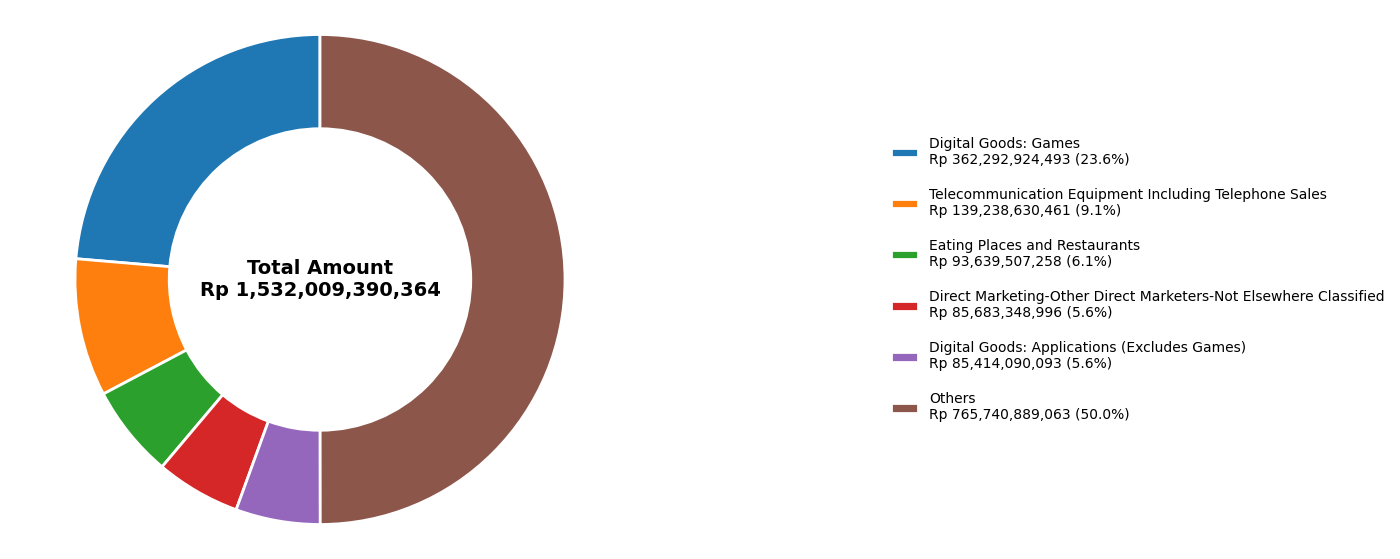

In [20]:
total_all = pie_data.sum()
legend_labels = [
    f"{idx}\nRp {val:,.0f} ({(val/total_all)*100:.1f}%)" 
    for idx, val in zip(pie_data.index, pie_data)
]

fig, ax = plt.subplots(figsize=(8, 7))

wedges, _ = ax.pie(
    pie_data, 
    startangle=90, 
    colors=plt.cm.tab10.colors,
    radius=1.3,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

ax.text(
    0, 0, 
    f"Total Amount\nRp {total_all:,.0f}", 
    ha='center', va='center', 
    fontsize=14, fontweight='bold'
)

ax.legend(
    wedges, legend_labels, 
    loc="center left", 
    bbox_to_anchor=(1.4, 0.5), 
    frameon=False, 
    labelspacing=1.5
)

plt.axis('equal') 

plt.show()